In [39]:
from pathlib import Path
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "strings").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
import sys
sys.path.append("..")
import numpy as np
import emcee
import matplotlib.pyplot as plt
import matplotlib as mpl
from getdist import plots, MCSamples
from tqdm import tqdm
from matplotlib.lines import Line2D
import os

TEX_BIN = "/Library/TeX/texbin"
if Path(TEX_BIN).exists() and TEX_BIN not in os.environ.get("PATH", "").split(":"):
    os.environ["PATH"] = f"{TEX_BIN}:{os.environ.get('PATH', '')}"

mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Computer Modern Roman"]


In [40]:
%load_ext autoreload
%autoreload 2
import strings as cs

BACKEND = "fortran" 

if BACKEND == "fortran":
    sys.path.insert(0, str(PROJECT_ROOT / "fortran_backend"))
    import cosmic_cl_backend as fcl

    compute_cl_backend = fcl.compute_cl
    theory_settings = dict(
        n_k=48,
        n_chi=1024,
        k_min=1.0e-4,
        k_max=1.0e-1,
    )
elif BACKEND == "python":
    compute_cl_backend = cs.compute_cl
    theory_settings = dict(
        N_k=30,
        max_workers=8,
        progress=True,
    )
else:
    raise ValueError("BACKEND must be 'fortran' or 'python'")

BACKEND, theory_settings


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


('fortran', {'n_k': 48, 'n_chi': 1024, 'k_min': 0.0001, 'k_max': 0.1})

In [41]:
ACT = cs.ACTDR6
PLANCK = cs.PLANCK13


In [42]:
def chi2_act(model):
    return np.sum(((ACT.CL - model) / ACT.ER)**2)

def chi2_planck(model):
    return np.sum(((PLANCK.CL - model) / PLANCK.ER)**2)

In [43]:
Gmu_vals = np.logspace(-10, -7, 60)   # vertical axis
P_vals   = np.logspace(-8, -2, 60)    # horizontal axis

In [44]:

chi2_grid_act = np.zeros((len(Gmu_vals), len(P_vals)))
chi2_grid_planck = np.zeros((len(Gmu_vals), len(P_vals)))
for i, P in tqdm(enumerate(P_vals), total=len(P_vals)):
    for j, Gmu in enumerate(Gmu_vals):
        if j == 0:
            ref_planck = compute_cl_backend(Gmu, P, ell_arr=PLANCK.L)
            ref_act = compute_cl_backend(Gmu, P, ell_arr=ACT.L)

            gmu_ref = Gmu
            
            chi2_grid_act[j, i] = chi2_act(ref_act)
            chi2_grid_planck[j, i] = chi2_planck(ref_planck)

        else:
            chi2_grid_act[j, i] = chi2_act(ref_act * (Gmu / gmu_ref)**2)
            chi2_grid_planck[j, i] = chi2_planck(ref_planck  * (Gmu / gmu_ref)**2)


100%|██████████| 60/60 [00:59<00:00,  1.01it/s]


In [45]:
chi2_grid_total = chi2_grid_act + chi2_grid_planck

In [46]:
chi2_min_act = np.min(chi2_grid_act)
chi2_min_total = np.min(chi2_grid_total)
delta_chi2_act = chi2_grid_act - chi2_min_act
delta_chi2_total = chi2_grid_total - chi2_min_total

In [21]:
# 2σ region
mask_2sigma_act = delta_chi2_act <= 6.18
mask_2sigma_total = delta_chi2_total <= 6.18

# Build grid arrays
Gmu_grid = Gmu_vals[:, None]
P_grid   = P_vals[None, :]

# Compute x = Gmu / P
x_grid = Gmu_grid / P_grid

# Extract allowed values
x_allowed_act = x_grid[mask_2sigma_act]
x_allowed_total = x_grid[mask_2sigma_total]

# Upper limit
x_upper_act = np.max(x_allowed_act)
x_upper_total = np.max(x_allowed_total)

print(f"2σ upper limit on Gμ P^-1 (ACT) = {x_upper_act:.3e}")
print(f"2σ upper limit on Gμ P^-1 (Total) = {x_upper_total:.3e}")


2σ upper limit on Gμ P^-1 (ACT) = 3.625e-05
2σ upper limit on Gμ P^-1 (Total) = 3.225e-05


In [47]:
Pgks, Ggks = np.loadtxt("../data/gks.txt", unpack=True)


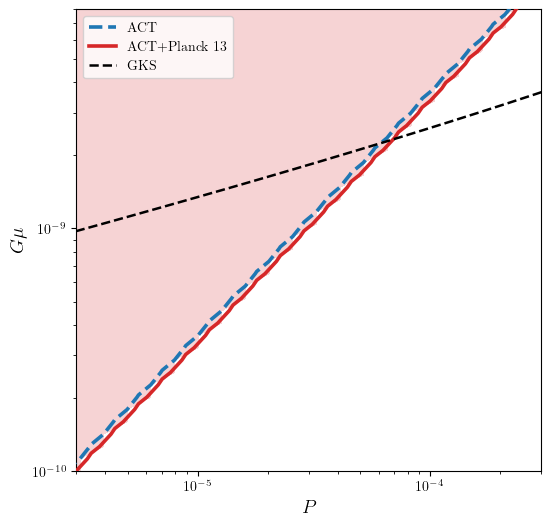

In [64]:
# Frequentist-only summary plot: shade ACT+Planck13 exclusion only
P_mesh, Gmu_mesh = np.meshgrid(P_vals, Gmu_vals)

fig, ax = plt.subplots(figsize=(6,6))

sigma2_level = 6.18
act_color = "tab:blue"
total_color = "tab:red"

total_excluded = (delta_chi2_total > sigma2_level).astype(float)

# Shade only the ACT+Planck13 excluded region.
ax.contourf(
    P_mesh,
    Gmu_mesh,
    total_excluded,
    levels=[0.5, 1.5],
    colors=[total_color],
    alpha=0.20,
    zorder=1,
)

ax.contour(
    P_mesh,
    Gmu_mesh,
    delta_chi2_act,
    levels=[sigma2_level],
    colors=[act_color],
    linewidths=2.6,
    linestyles="--",
    zorder=3,
 )
ax.contour(
    P_mesh,
    Gmu_mesh,
    delta_chi2_total,
    levels=[sigma2_level],
    colors=[total_color],
    linewidths=2.6,
    linestyles="-",
    zorder=4,
 )
ax.plot(Pgks, Ggks / 4.0, "k--", linewidth=1.8, zorder=5)

# Keep legend focused on boundaries + GKS only.
legend_elements = [
    Line2D([0], [0], color=act_color, linestyle="--", lw=2.6, label=r"ACT"),
    Line2D([0], [0], color=total_color, linestyle="-", lw=2.6, label=r"ACT+Planck 13"),
    Line2D([0], [0], color="black", linestyle="--", lw=1.8, label="GKS"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=10)

# Keep log scales and zoom into the region where boundaries are easiest to compare.
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(3e-6, 3e-4)
ax.set_ylim(1e-10, 8e-9)
ax.set_xlabel(r"$P$", fontsize=14)
ax.set_ylabel(r"$G\mu$", fontsize=14)

plt.savefig("plots/GmuPinv_Constraint_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()
